# Test climatology of generated time series

One could hypothesize that the annual cycle gets distorted by our sampling methodology.

Possible analyses:
- what's the relation between sampled date and output date in time series? Is there a systematic shift? How does this vary when varying $\sigma$?
- could look at analyses for individual locations (plot climatologies etc)
- comparing average temperatures for each day of the year between ERA5 and weather generators
- plot a few temperature time series for Leipzig for generated years and true years

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib as mpl
import matplotlib.pyplot as plt

import xarray as xr
from analyses.utils import (
    extract_n_years_from_trajectory,
    load_trajectories,
    extract_datapoints_in_years,
    stack_to_dim,
)
from unseen_awg.plotting_utils import add_label_to_axes

import cmcrameri as cmc

import matplotlib.gridspec as gridspec
from itertools import product
import os
import yaml
import numpy as np

In [3]:
mpl.rc_file("../../matplotlibrc")

with open("../../configs/paths.yaml") as file:
    paths = yaml.safe_load(file)["paths"]

In [4]:
n_seeds = 500
sigmas = [0.25, 2.5, 250]
blocksizes = [1, 30, 44]
paths_trajectories = [
    os.path.join(
        paths["dir_simulations"],
        "wg_reforecasts_5e06172f_f40e9460_1e69bda9_d13ad10f",
        f"{seed}_{sigma:g}_{blocksize}",
    )
    for (seed, sigma, blocksize) in product(np.arange(n_seeds), sigmas, blocksizes)
]

N_YEARS = 21
YEAR_MIN = 2003
YEAR_MAX = YEAR_MIN + N_YEARS - 1

In [5]:
ds_era5 = xr.open_zarr(
    os.path.join(
        paths["dir_preprocessed_datasets"],
        "preprocessed_impact_variables_era5",
        "combined_facc0e91.zarr",
    ),
    decode_timedelta=True,
)
ds_reforecasts_bias_corrected = xr.open_zarr(
    os.path.join(
        paths["dir_preprocessed_datasets"],
        "preprocessed_impact_variables_reforecasts",
        "rechunk_combined-corrected_facc0e91_7d1d3d97_884a804a_3f7e331d.zarr",
    ),
    decode_timedelta=True,
)

In [6]:
ds_era5 = ds_era5.assign_coords(
    {"valid_time": ds_era5.init_time.data[0] + ds_era5.lead_time}
)
ds_reforecasts_bias_corrected = ds_reforecasts_bias_corrected.assign_coords(
    {
        "valid_time": ds_reforecasts_bias_corrected.init_time
        + ds_reforecasts_bias_corrected.lead_time
    }
)


ground_truth = (
    extract_datapoints_in_years(
        stack_to_dim(ds_era5),
        year_max=YEAR_MAX,
        year_min=YEAR_MIN,
    ).swap_dims({"datapoint": "valid_time"})
).expand_dims()

excl_vars = ["tp"]
sel_vars = [v for v in ground_truth.data_vars if v not in excl_vars]

trajectories = load_trajectories(paths_trajectories)

print("load trajectories")
trimmed_trajs = []
for traj in trajectories:
    trimmed_trajs.append(
        extract_n_years_from_trajectory(
            traj=traj,
            n_years=N_YEARS,
            new_start_year=ground_truth.valid_time.dt.year.min().data,
        )
    )
trimmed_trajs = xr.combine_by_coords(trimmed_trajs)

load trajectories


In [7]:
# for simplicity in the analysis, exclude winter
trimmed_trajs_ss = trimmed_trajs.where(
    trimmed_trajs.out_time.dt.season != "DJF", drop=True
)


In [8]:
trimmed_trajs_ss["valid_time"] = (
    trimmed_trajs_ss["init_time"] + trimmed_trajs_ss["lead_time"]
)

In [9]:
trimmed_trajs_ss["diff_out_time_valid_time"] = (
    trimmed_trajs_ss["out_time"].dt.dayofyear
    - trimmed_trajs_ss["valid_time"].dt.dayofyear
)

(array([[  9553.,  13787.,  23661.,  17959.,  24982.,  39399.,  46292.,
          45253.,  52853.,  56981., 101008., 168603., 182387., 194760.,
         200801., 218156., 240556., 241884., 264435., 241396., 269168.,
         210989.],
        [ 31152., 101754., 116496., 123088., 128789., 134387., 139998.,
         145842., 151048., 156004., 162253., 162969., 158362., 154181.,
         149316., 143779., 139933., 133904., 126973., 122375., 118031.,
          78904.]]),
 array([-11.5, -10.5,  -9.5,  -8.5,  -7.5,  -6.5,  -5.5,  -4.5,  -3.5,
         -2.5,  -1.5,  -0.5,   0.5,   1.5,   2.5,   3.5,   4.5,   5.5,
          6.5,   7.5,   8.5,   9.5,  10.5]),
 <a list of 2 list[Polygon] objects>)

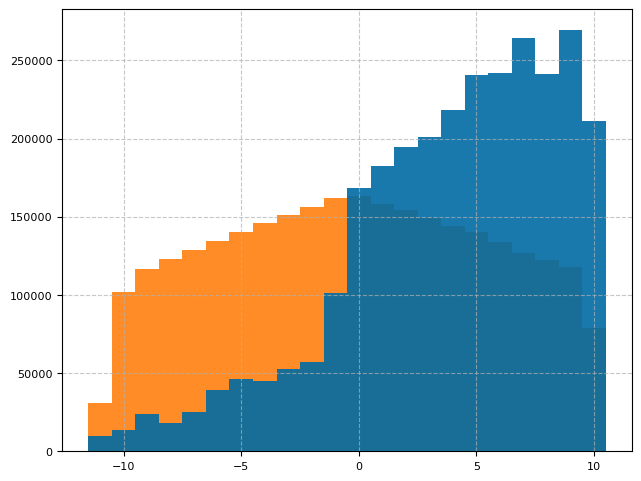

In [10]:
plt.hist(
    [
        trimmed_trajs_ss["diff_out_time_valid_time"]
        .sel(blocksize=1, sigma=s)
        .stack(stacked_dim=("out_time", "seed"))
        .squeeze()
        for s in [0.25, 2.5]
    ],
    bins=np.arange(-11.5, 11.5),
    label=[r"$\sigma=$" + f"{s.data}" for s in trimmed_trajs_ss.sigma],
    histtype="stepfilled",
    alpha=0.9,
)


In [11]:
area_weights = np.cos(np.deg2rad(ds_reforecasts_bias_corrected.latitude))

In [12]:
num_workers = 3
t2m_wg_reforecasts_bias_corrected = (
    ds_reforecasts_bias_corrected["t2m"]
    .weighted(area_weights)
    .mean(("longitude", "latitude"))
    .load(num_workers=num_workers)
    .sel(trimmed_trajs)
)
"""t2m_wg_era = (
    ds_era["t2m"]
    .mean(("latitude", "longitude"))
    .load(num_workers=num_workers)
    .sel(trimmed_trajs.sel(WG="ERA5_2003_2023", sigma=4.0))
)"""
t2m_era5 = (
    ds_era5["t2m"]
    .weighted(area_weights)
    .mean(("longitude", "latitude"))
    .load(num_workers=num_workers)
)

In [13]:
clim_t2m_era5 = t2m_era5.groupby("valid_time.dayofyear").mean().squeeze()

"""clim_t2m_wg_era = []
for sigma in t2m_wg_era.sigma:
    for tauin t2m_wg_era.blocksize:
        clim_t2m_wg_era.append(
            t2m_wg_era.groupby("valid_time.dayofyear")
            .mean()
            .squeeze()
            .expand_dims(sigma=[sigma.data], blocksize=[tau.data])
        )"""

# clim_t2m_wg_era = xr.combine_by_coords(clim_t2m_wg_era)["t2m"]

clim_t2m_wg_reforecasts_bias_corrected = []
for sigma in t2m_wg_reforecasts_bias_corrected.sigma:
    for tau in t2m_wg_reforecasts_bias_corrected.blocksize:
        for s in t2m_wg_reforecasts_bias_corrected.seed:
            clim_t2m_wg_reforecasts_bias_corrected.append(
                t2m_wg_reforecasts_bias_corrected.sel(
                    sigma=sigma, blocksize=tau, seed=s
                )
                .groupby("out_time.dayofyear")
                .mean()
                .squeeze()
                .expand_dims(sigma=[sigma.data], blocksize=[tau.data], seed=[s.data])
            )

clim_t2m_wg_reforecasts_bias_corrected = xr.combine_by_coords(
    clim_t2m_wg_reforecasts_bias_corrected
)["t2m"]

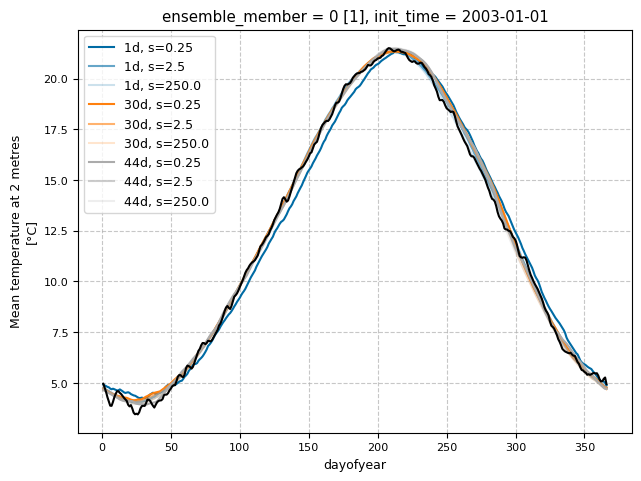

In [14]:
for i, tau in enumerate(clim_t2m_wg_reforecasts_bias_corrected.blocksize):
    for j, sigma in enumerate(clim_t2m_wg_reforecasts_bias_corrected.sigma):
        clim_t2m_wg_reforecasts_bias_corrected.sel(sigma=sigma, blocksize=tau).mean(
            "seed"
        ).plot(c=f"C{i}", label=f"{tau.data}d, s={sigma.data}", alpha=1 - 0.4 * j)

clim_t2m_era5.plot(color="k")
plt.legend()

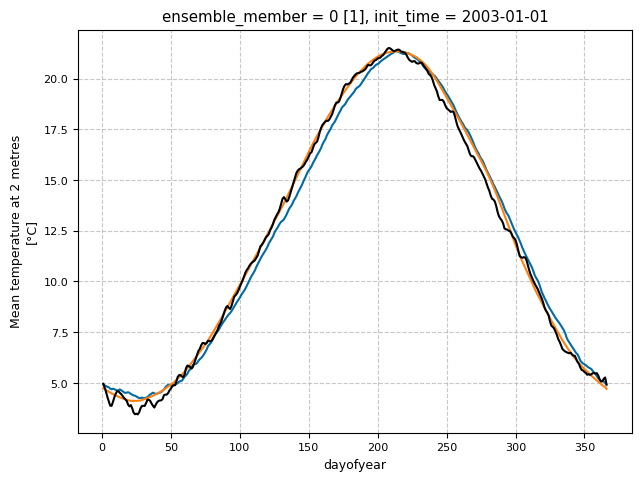

In [15]:
clim_t2m_wg_reforecasts_bias_corrected.sel(sigma=0.25, blocksize=1).mean("seed").plot()

clim_t2m_wg_reforecasts_bias_corrected.sel(sigma=2.5, blocksize=30).mean("seed").plot()
clim_t2m_era5.plot(color="k")

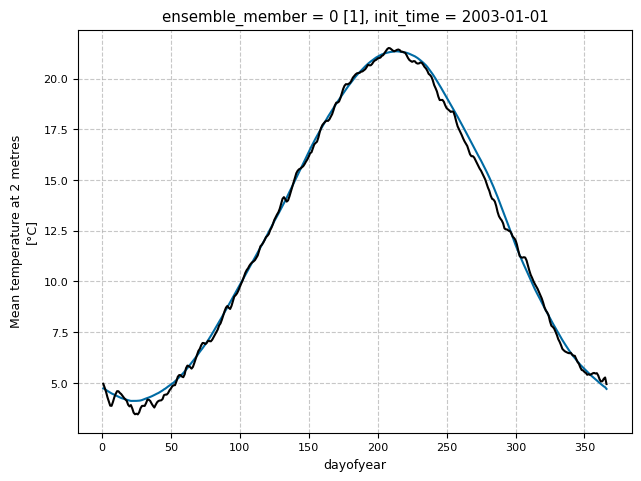

In [16]:
clim_t2m_wg_reforecasts_bias_corrected.sel(sigma=2.5, blocksize=30).mean("seed").plot()
clim_t2m_era5.plot(color="k")

In [17]:
COORDS_LEIPZIG = {"latitude": 51.340199, "longitude": 12.360103}

In [18]:
t2m_leipzig_reforecasts_bias_corrected = (
    ds_reforecasts_bias_corrected.sel(COORDS_LEIPZIG, method="nearest")["t2m"]
    .load()
    .sel(trimmed_trajs)
)
t2m_leipzig_era5 = ds_era5.sel(COORDS_LEIPZIG, method="nearest")["t2m"].load()
t2m_leipzig_era5 = t2m_leipzig_era5.assign_coords(
    valid_time=t2m_leipzig_era5.lead_time + t2m_leipzig_era5.init_time
).squeeze()

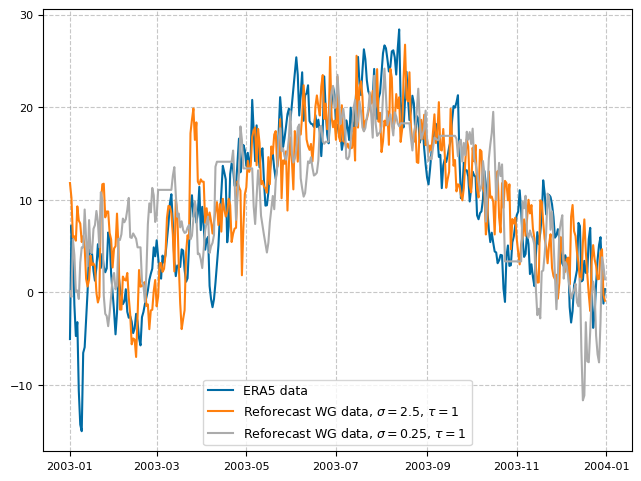

In [19]:
sample_year_era5_leipzig = t2m_leipzig_era5.where(
    t2m_leipzig_era5.valid_time.dt.year == 2003, drop=True
)

plt.plot(
    sample_year_era5_leipzig.valid_time, sample_year_era5_leipzig, label="ERA5 data"
)

for sigma, blocksize in zip([2.5, 0.25], [1, 1]):
    sample_year_wg_reforecasts_bias_corrected_leipzig = (
        t2m_leipzig_reforecasts_bias_corrected.sel(sigma=sigma, blocksize=blocksize)
        .isel(seed=0)
        .where(
            t2m_leipzig_reforecasts_bias_corrected.out_time.dt.year == 2003, drop=True
        )
    ).squeeze()  # .plot(label="ERA5 2003 data")
    plt.plot(
        sample_year_wg_reforecasts_bias_corrected_leipzig.out_time,
        sample_year_wg_reforecasts_bias_corrected_leipzig,
        label=rf"Reforecast WG data, $\sigma=${sigma}, $\tau=${blocksize}",
    )

plt.legend(loc="best")

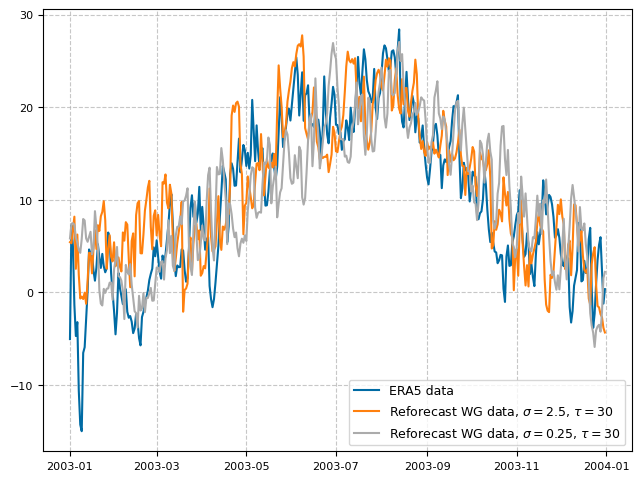

In [20]:
sample_year_era5_leipzig = t2m_leipzig_era5.where(
    t2m_leipzig_era5.valid_time.dt.year == 2003, drop=True
)

plt.plot(
    sample_year_era5_leipzig.valid_time, sample_year_era5_leipzig, label="ERA5 data"
)

for sigma, blocksize in zip([2.5, 0.25], [30, 30]):
    sample_year_wg_reforecasts_bias_corrected_leipzig = (
        t2m_leipzig_reforecasts_bias_corrected.sel(sigma=sigma, blocksize=blocksize)
        .isel(seed=0)
        .where(
            t2m_leipzig_reforecasts_bias_corrected.out_time.dt.year == 2003, drop=True
        )
    ).squeeze()  # .plot(label="ERA5 2003 data")
    plt.plot(
        sample_year_wg_reforecasts_bias_corrected_leipzig.out_time,
        sample_year_wg_reforecasts_bias_corrected_leipzig,
        label=rf"Reforecast WG data, $\sigma=${sigma}, $\tau=${blocksize}",
    )

plt.legend(loc="best")

/tmp/ipykernel_1018802/2237194829.py:133: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


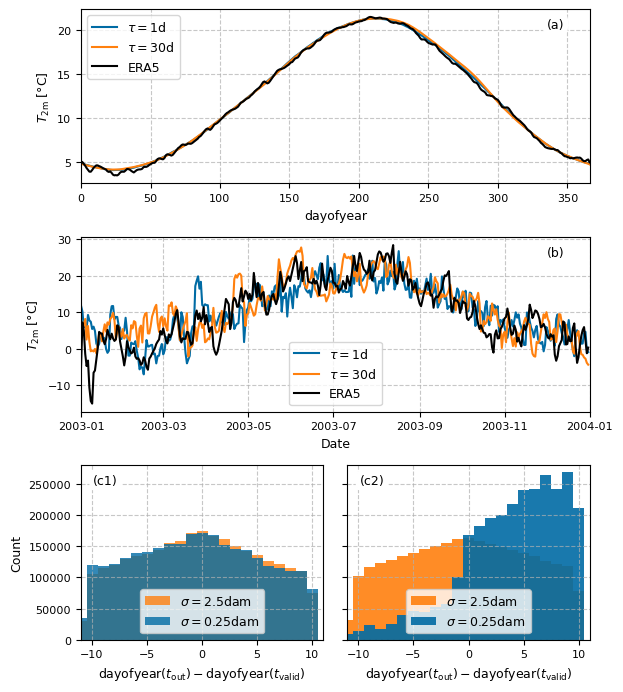

In [27]:
fig = plt.figure()

fig.set_figheight(7)

gs = gridspec.GridSpec(3, 1, figure=fig)

sub_gs = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=gs[-1], wspace=0.1)


# compare climatologies of ERA5 and generated time series:
ax_climatology = fig.add_subplot(gs[0])
ax_time_series = fig.add_subplot(gs[1])
ax_lag_tau_30 = fig.add_subplot(sub_gs[0])
ax_lag_tau_1 = fig.add_subplot(sub_gs[1])

for i, tau in enumerate(
    clim_t2m_wg_reforecasts_bias_corrected.blocksize.sel(blocksize=slice(1, 30))
):
    for j, sigma in enumerate([2.5]):
        clim_t2m_wg_reforecasts_bias_corrected.mean("seed").sel(
            sigma=sigma, blocksize=tau
        ).plot(
            ax=ax_climatology,
            c=f"C{i}",
            label=rf"$\tau=${tau.data}d",
            alpha=1 - 0.4 * j,
        )

clim_t2m_era5.plot(
    ax=ax_climatology,
    color="k",
    label="ERA5",
)
ax_climatology.legend()
ax_climatology.set_title("")
ax_climatology.set_ylabel(r"$T_\mathrm{2m}$ [°C]")
ax_climatology.set_xlim(0, 366)


# plot generated and real time series
sample_year_era_leipzig = t2m_leipzig_era5.where(
    t2m_leipzig_era5.valid_time.dt.year == 2003, drop=True
)


for sigma, blocksize in zip([2.5, 2.5], [1, 30]):
    sample_year_wg_reforecasts_bias_corrected_leipzig = (
        t2m_leipzig_reforecasts_bias_corrected.sel(sigma=sigma, blocksize=blocksize)
        .isel(seed=0)
        .where(
            t2m_leipzig_reforecasts_bias_corrected.out_time.dt.year == 2003, drop=True
        )
    ).squeeze()  # .plot(label="ERA5 2003 data")
    ax_time_series.plot(
        sample_year_wg_reforecasts_bias_corrected_leipzig.out_time,
        sample_year_wg_reforecasts_bias_corrected_leipzig,
        label=rf"$\tau=${blocksize}d",
    )
ax_time_series.plot(
    sample_year_era_leipzig.valid_time, sample_year_era_leipzig, label="ERA5", color="k"
)
ax_time_series.set_ylabel(r"$T_\mathrm{2m}$ [°C]")
ax_time_series.legend(loc="best")
ax_time_series.set_xlabel(r"Date")
ax_time_series.set_xlim(
    np.datetime64("2003-01-01", "ns"), np.datetime64("2004-01-01", "ns")
)


ax_lag_tau_1.hist(
    [
        trimmed_trajs_ss["diff_out_time_valid_time"]
        .sel(blocksize=1, sigma=s)
        .stack(stacked_dim=("out_time", "seed"))
        .squeeze()
        for s in [0.25, 2.5]
    ],
    bins=np.arange(-11.5, 11.5),
    label=[r"$\sigma=$" + f"{s.data}dam" for s in trimmed_trajs_ss.sigma],
    histtype="stepfilled",
    alpha=0.9,
)

ax_lag_tau_30.hist(
    [
        trimmed_trajs_ss["diff_out_time_valid_time"]
        .sel(blocksize=30, sigma=s)
        .stack(stacked_dim=("out_time", "seed"))
        .squeeze()
        for s in [0.25, 2.5]
    ],
    bins=np.arange(-11.5, 11.5),
    label=[r"$\sigma=$" + f"{s.data}dam" for s in trimmed_trajs_ss.sigma],
    histtype="stepfilled",
    alpha=0.8,
)

ax_lag_tau_30.legend(loc="lower center")
ax_lag_tau_1.legend(loc="lower center")

ax_lag_tau_30.set_ylabel("Count")
ax_lag_tau_1.set_yticklabels([])
ax_lag_tau_1.set_ylabel("")

ax_lag_tau_30.set_ylim(0, 280000)
ax_lag_tau_1.set_ylim(0, 280000)
ax_lag_tau_30.set_xlim(-11, 11)
ax_lag_tau_1.set_xlim(-11, 11)


ax_lag_tau_30.set_xlabel(
    r"$\text{dayofyear}(t_\mathrm{out}) - \text{dayofyear}(t_\mathrm{valid})$"
)
ax_lag_tau_1.set_xlabel(
    r"$\text{dayofyear}(t_\mathrm{out}) - \text{dayofyear}(t_\mathrm{valid})$"
)


font_kwargs = dict(fontweight="bold", fontsize="large")
add_label_to_axes(
    ax=ax_climatology, label="(a)", ax_xpos=0.95, ax_ypos=0.95, va="top", ha="right"
)
add_label_to_axes(
    ax=ax_time_series, label="(b)", ax_xpos=0.95, ax_ypos=0.95, va="top", ha="right"
)
add_label_to_axes(
    ax=ax_lag_tau_30, label="(c1)", ax_xpos=0.05, ax_ypos=0.95, va="top", ha="left"
)
add_label_to_axes(
    ax=ax_lag_tau_1, label="(c2)", ax_xpos=0.05, ax_ypos=0.95, va="top", ha="left"
)

plt.tight_layout()
plt.savefig(os.path.join(paths["dir_images"], "climatology_diagnostics.pdf"), dpi=300)

/tmp/ipykernel_1018802/2410202033.py:63: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


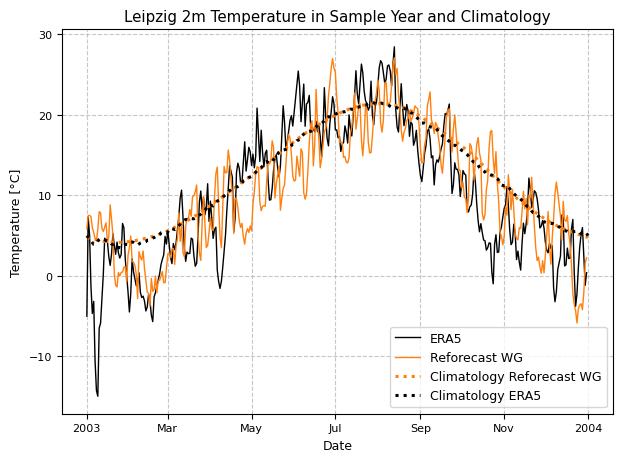

In [22]:
sample_year_era5_leipzig = t2m_leipzig_era5.where(
    t2m_leipzig_era5.valid_time.dt.year == 2003, drop=True
)

plt.plot(
    sample_year_era5_leipzig.valid_time,
    sample_year_era5_leipzig,
    label="ERA5",
    color="k",
    lw=1,
)

for sigma, blocksize in zip([0.25], [30]):
    sample_year_wg_reforecasts_bias_corrected_leipzig = (
        t2m_leipzig_reforecasts_bias_corrected.sel(sigma=sigma, blocksize=blocksize)
        .isel(seed=0)
        .where(
            t2m_leipzig_reforecasts_bias_corrected.out_time.dt.year == 2003, drop=True
        )
    ).squeeze()  # .plot(label="ERA5 2003 data")
    plt.plot(
        sample_year_wg_reforecasts_bias_corrected_leipzig.out_time,
        sample_year_wg_reforecasts_bias_corrected_leipzig,
        label="Reforecast WG",
        lw=1,
        color="C1",
    )


for i, tau in enumerate(
    [clim_t2m_wg_reforecasts_bias_corrected.blocksize.sel(blocksize=30)]
):
    for j, sigma in enumerate([2.5]):
        data = clim_t2m_wg_reforecasts_bias_corrected.assign_coords(
            dayofyear=np.datetime64("2003-01-01")
            + (clim_t2m_wg_reforecasts_bias_corrected.dayofyear - 1)
            * np.timedelta64(1, "D")
        )
        data.mean("seed").sel(sigma=sigma, blocksize=tau).plot(
            # c=f"C{i}",
            label="Climatology Reforecast WG",
            linestyle="dotted",
            color="C1",
            lw=2.2,
        )
data = clim_t2m_era5.assign_coords(
    dayofyear=np.datetime64("2003-01-01")
    + (clim_t2m_era5.dayofyear - 1) * np.timedelta64(1, "D")
)
data.plot(
    color="k",
    label="Climatology ERA5",
    linestyle="dotted",
    lw=2.2,
)

plt.ylabel("Temperature [°C]")
plt.xlabel("Date")

plt.legend(loc="best")
plt.title("Leipzig 2m Temperature in Sample Year and Climatology")

plt.tight_layout()
plt.savefig(os.path.join(paths["dir_images"], "climatology_diagnostics_simplified.png"))

(array([[  9553.,  13787.,  23661.,  17959.,  24982.,  39399.,  46292.,
          45253.,  52853.,  56981., 101008., 168603., 182387., 194760.,
         200801., 218156., 240556., 241884., 264435., 241396., 269168.,
         210989.,  22637.],
        [ 31152., 101754., 116496., 123088., 128789., 134387., 139998.,
         145842., 151048., 156004., 162253., 162969., 158362., 154181.,
         149316., 143779., 139933., 133904., 126973., 122375., 118031.,
          78904.,   7951.]]),
 array([-11., -10.,  -9.,  -8.,  -7.,  -6.,  -5.,  -4.,  -3.,  -2.,  -1.,
          0.,   1.,   2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.,  10.,
         11.,  12.]),
 <a list of 2 list[Polygon] objects>)

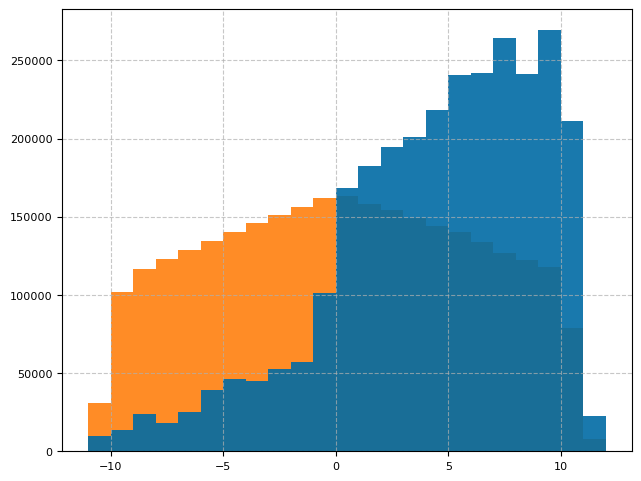

In [23]:
plt.hist(
    [
        trimmed_trajs_ss["diff_out_time_valid_time"]
        .sel(blocksize=1, sigma=s)
        .stack(stacked_dim=("out_time", "seed"))
        .squeeze()
        for s in [0.25, 2.5]
    ],
    bins=np.linspace(-11, 12, 24),
    label=[r"$\sigma=$" + f"{s.data}" for s in trimmed_trajs_ss.sigma],
    histtype="stepfilled",
    alpha=0.9,
)